In [1]:
from tifffile import imread

from matplotlib import pyplot as plt

import numpy as np

from skimage.morphology import h_maxima

from spot_detection_utils import subpixel_localization, get_spot
from skimage.measure import regionprops
import napari

In [2]:
image = imread('/Users/abamford/Desktop/skimage-napari-tutorial/100tp_561-100-50ms-1000g_10_conf561_merged.tif')

In [3]:
denoised_img = image[:, 0]
raw_img = image[:, 1]

In [4]:
mask = imread('/Users/abamford/Desktop/skimage-napari-tutorial/100tp_561-100-50ms-1000g_10_conf561_merged_ROI1-5.tif')

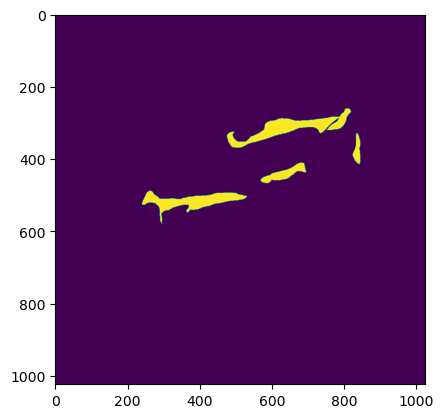

In [5]:
plt.imshow(mask > 0)

In [55]:
# Mask out foreground (mask > 0) --> go from instance segmentation to semantic segmentation (fg vs bg)
masked_cells = denoised_img * (mask > 0)

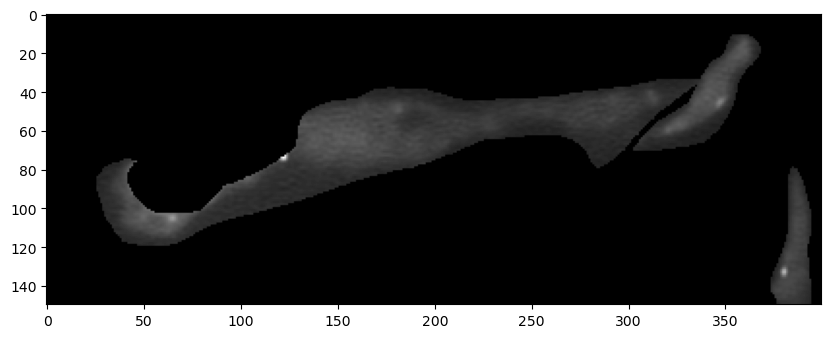

In [71]:
frame = 82
plt.figure(figsize=(10,10))
plt.imshow(masked_cells[frame, 250:400,450:850], cmap='gray')

In [8]:
from skimage.morphology import disk

In [72]:
# TODO: How to choose threshold? Is standard deviation a good choice?
threshold = int(np.std(denoised_img[frame, mask > 0]))
spots = h_maxima(image=denoised_img[frame], footprint=disk(1), h=threshold)
spots = spots * (mask > 0)

In [10]:
disk(1)

array([[0, 1, 0],
       [1, 1, 1],
       [0, 1, 0]], dtype=uint8)

In [11]:
from matplotlib.colors import ListedColormap
spot_cmap = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 1]])

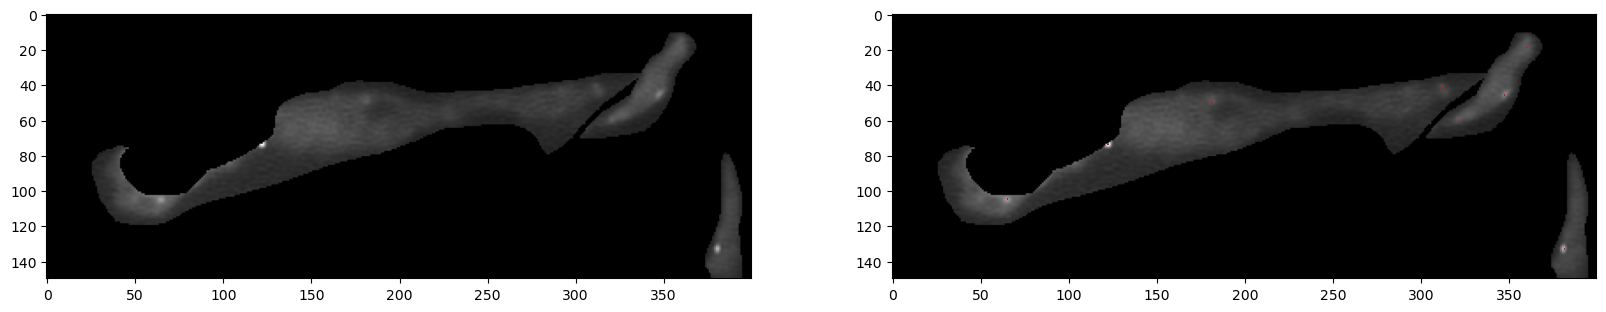

In [74]:
plt.figure(figsize=(20, 10))
plt.subplot(1,2,1)
plt.imshow(masked_cells[frame, 250:400,450:850], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(masked_cells[frame, 250:400,450:850], cmap='gray')
plt.imshow(spots[250:400,450:850], cmap=spot_cmap)

In [75]:
# Assign spots to ROIs
spots_per_roi = []
roi_labels = list(filter(None, np.unique(mask)))

for label_id in roi_labels:
    spots_per_roi.append(np.where(spots * (mask == label_id)))

In [76]:
roi_labels

[1, 2, 3, 4, 5]

In [77]:
spots_per_roi

[(array([515, 518, 520, 522, 523, 523, 526, 531, 534, 543]),
  array([440, 359, 364, 331, 375, 381, 323, 299, 322, 369])),
 (array([448, 458]), array([631, 580])),
 (array([291, 294, 300, 324, 355]), array([762, 763, 631, 572, 515])),
 (array([269, 296, 310]), array([810, 797, 771])),
 (array([383]), array([831]))]

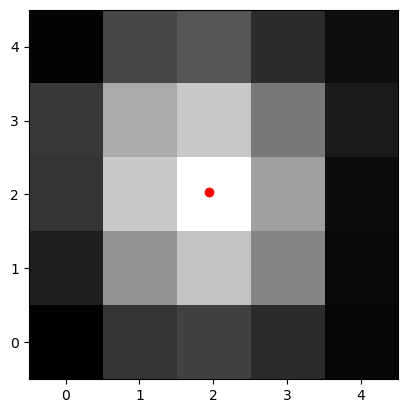

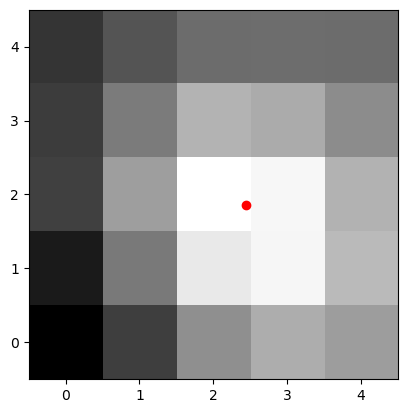

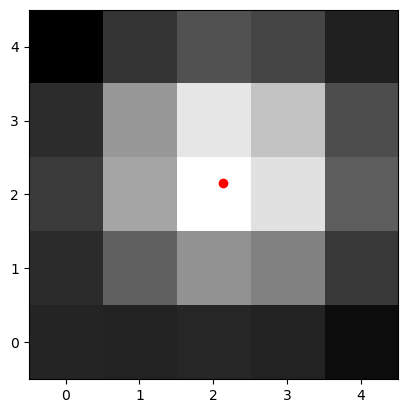

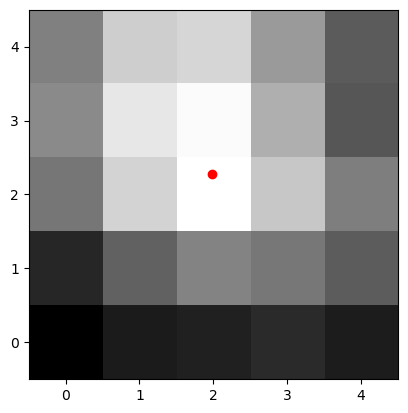

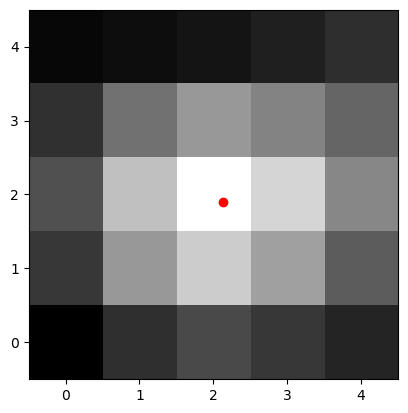

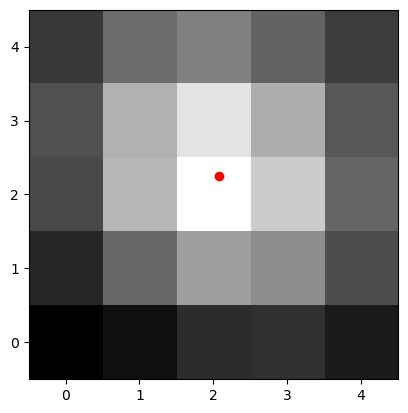

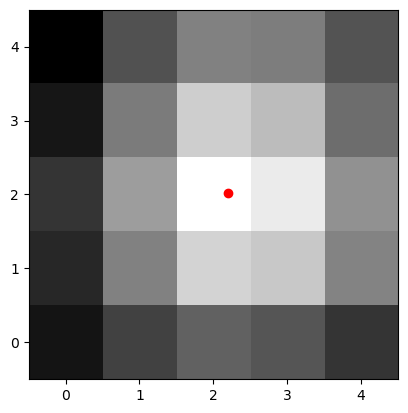

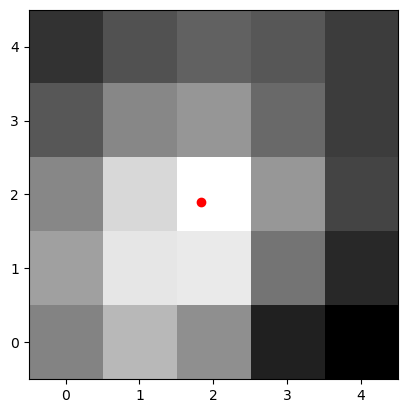

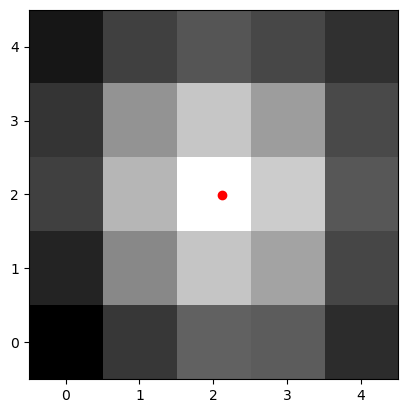

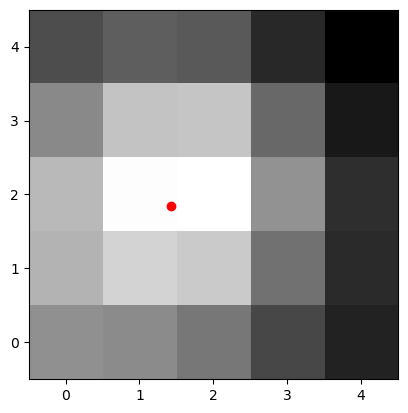

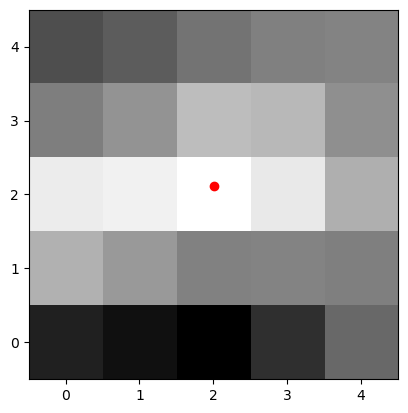

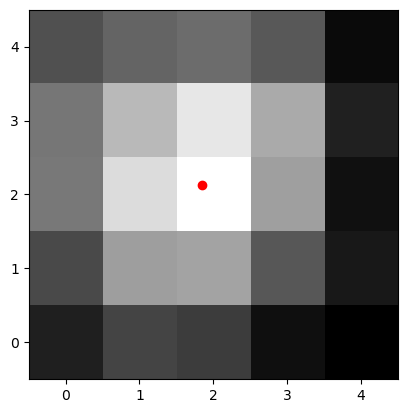

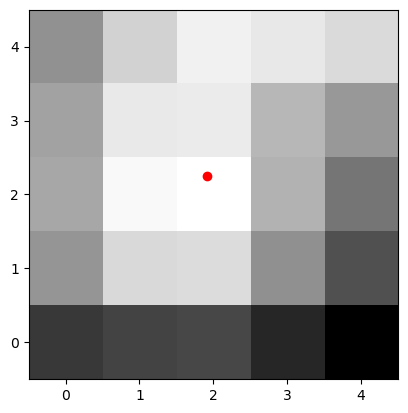

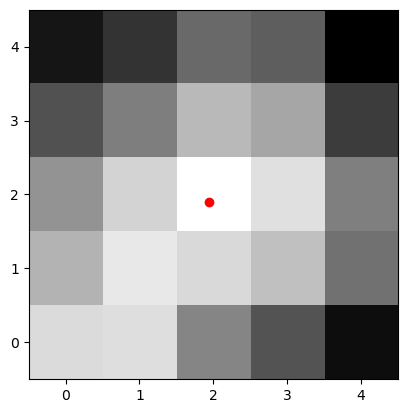

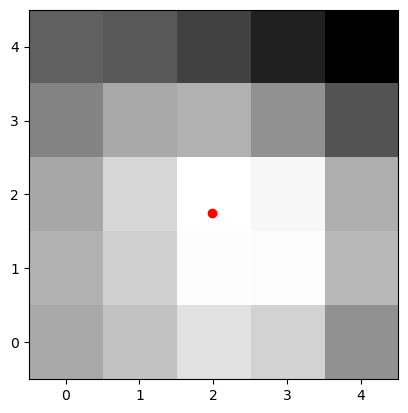

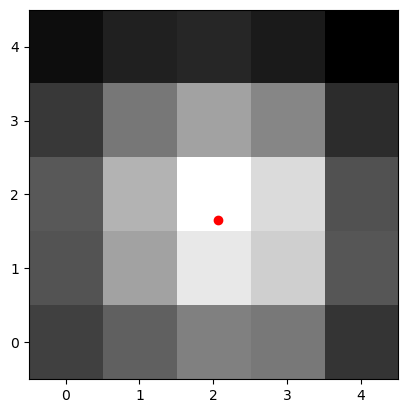

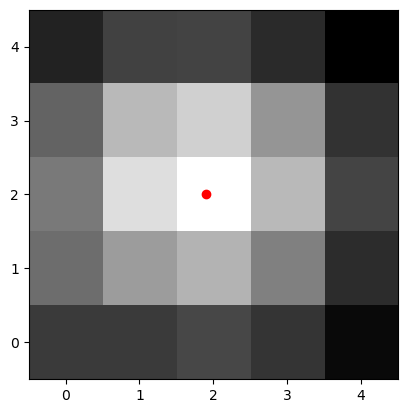

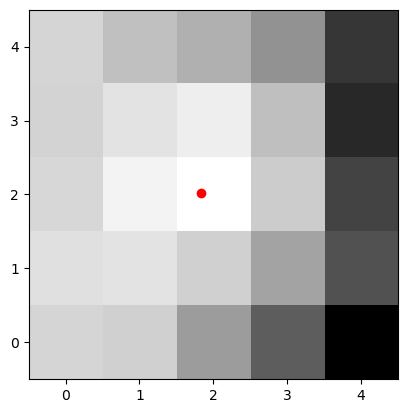

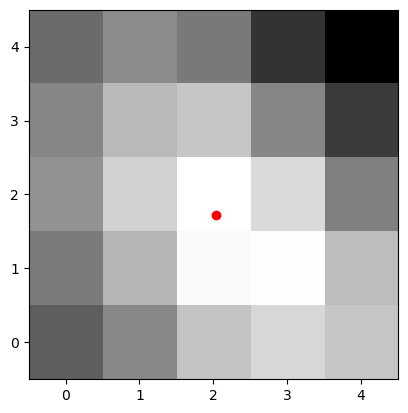

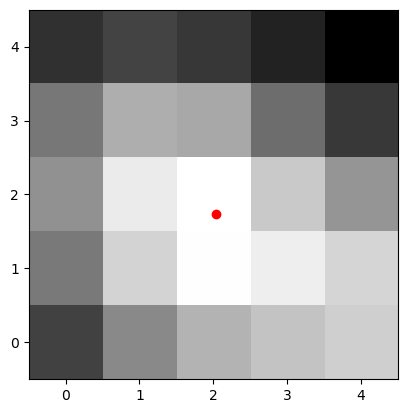

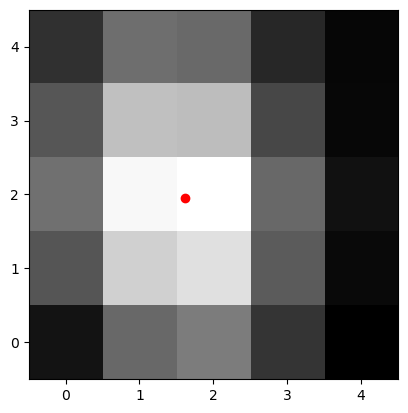

In [78]:
# subpixel localization of spots and visualization
spot_size = 3

subpix_spots = {}
for roi_id, (y_coords, x_coords) in zip(roi_labels, spots_per_roi):
    subpix_spots[roi_id] = []
    for y, x in zip(y_coords, x_coords):
        spot_img, start_y, start_x = get_spot(denoised_img[frame], [y, x], size=5)
        y_loc, x_loc = subpixel_localization(spot_img)
        plt.imshow(spot_img, cmap='gray', origin='lower')
        plt.plot(x_loc, y_loc, 'ro')
        plt.show()
        subpix_spots[roi_id].append([start_y + y_loc, start_x + x_loc])


In [79]:
features = regionprops(mask)

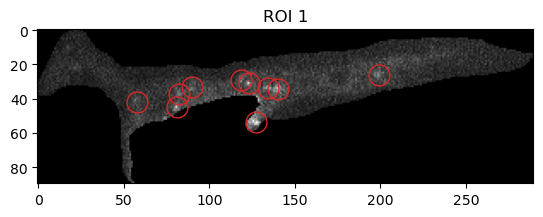

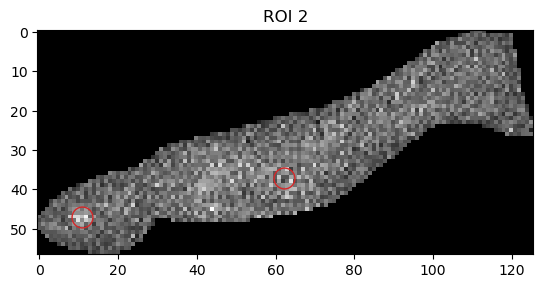

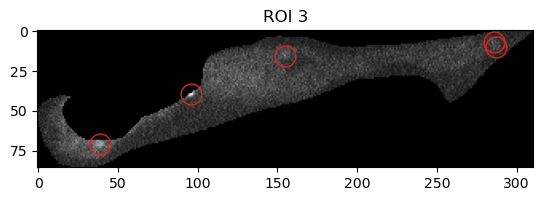

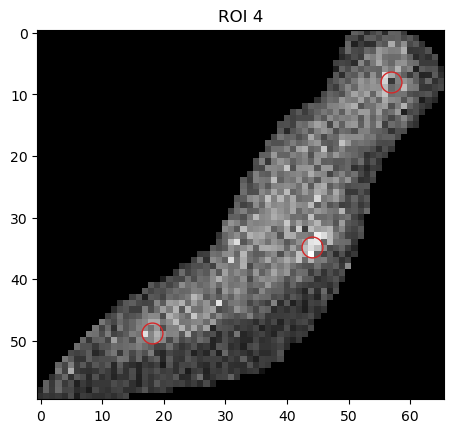

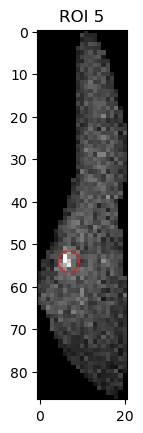

In [80]:
# Overlay subpixel localized spots on raw image frame.
marker_style = dict(color='tab:red', linestyle=':', marker='o',
                    markersize=15, markerfacecoloralt='tab:red')

for prop in features:
    box = prop.bbox
    plt.imshow((raw_img[frame] * (mask == prop.label))[box[0]:box[2], box[1]:box[3]], cmap='gray')
    for y, x in subpix_spots[prop.label]:
        plt.plot(x - box[1], y- box[0], fillstyle='none', **marker_style)

    plt.title(f'ROI {prop.label}')
    plt.show()

In [37]:
viewer = napari.Viewer()

In [38]:
viewer.add_image(denoised_img)
viewer.layers['denoised_img'].contrast_limits=(200,9000)

In [39]:
viewer.add_image(mask)

<Image layer 'mask' at 0x188ab7610>

In [32]:
import pandas as pd

In [33]:
dfs = []
for roi_id in subpix_spots:
    spot_df = pd.DataFrame(subpix_spots[roi_id], columns=['y', 'x'])
    spot_df['roi_id'] = roi_id
    spot_df['frame'] = frame

    dfs.append(spot_df)

spots_for_frame_df = pd.concat(dfs, ignore_index=True)
spots_for_frame_df = spots_for_frame_df.reindex(columns=['frame', 'roi_id', 'x', 'y'])

In [34]:
spots_for_frame_df

,frame,roi_id,x,y
0,80,1,436.915244,510.801248
1,80,1,424.988693,517.173614
2,80,1,372.930554,523.289763
3,80,1,391.067979,524.115254
4,80,1,323.328378,525.874282
5,80,1,298.024776,529.851413
6,80,1,372.836943,531.819966
7,80,1,369.704945,541.602717
8,80,2,664.043409,423.094899
9,80,2,579.749115,458.724773


In [41]:
# Array needs to be yx, because this is how coordinates are read in
array_yx=spots_for_frame_df[["y","x"]].to_numpy()
array_yx

array([[510.80124772, 436.91524421],
       [517.17361369, 424.98869297],
       [523.28976313, 372.93055383],
       [524.11525373, 391.06797936],
       [525.87428165, 323.32837756],
       [529.85141343, 298.02477618],
       [531.81996584, 372.83694261],
       [541.60271701, 369.70494489],
       [423.0948993 , 664.04340872],
       [458.72477293, 579.74911538],
       [299.13347785, 632.00857904],
       [307.76907755, 728.96947109],
       [311.00287213, 603.89826314],
       [311.03052128, 666.01222943],
       [356.83931718, 508.80842163],
       [294.99671232, 798.7779817 ],
       [381.92384057, 830.2136439 ]])

In [43]:
viewer.add_points(array_yx, size=5, edge_color='red', face_color='red')

<Points layer 'array_yx' at 0x185764d60>

In [ ]:
# Comments Aileen:
# We might be slightly underdetecting
# Slight overdetection is preferable, since wrong hits will be removed when tracking is done
# Should we do a more systematic comparison between denoised and raw images?
# How well can it resolve spots that are very close together?
# How can we avoid false positives at the edge of the ROI? - masking is done after spot detection, so spots at the edge of ROI are not an artefact